In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder,StandardScaler,OneHotEncoder

In [2]:
df=pd.read_csv(r"E:\DS\PROJECTS\EMPLOYEE ATTRITION ANALYSIS & PREDICTION\EMPLOYEE_ATTRITION_PROJECT\Employee-Attrition - Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.shape

(1470, 35)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
df.describe(include='all')


#From the above step, the dataset structure was explored to understand the number of records,
# features, data types, and basic statistical properties.
# This helps in identifying potential data quality issues before preprocessing.

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


In [7]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [8]:
drop_columns=['EmployeeCount',
              'Over18',
              'StandardHours',
              'EmployeeNumber']

df.drop(columns=drop_columns,inplace=True)

#In this step, non-informative and constant columns were removed from the dataset. 
# These features do not contribute to predictive modeling and may negatively impact model performance. 
# Removing them helps improve model efficiency and interpretability

In [9]:
df.shape

(1470, 31)

In [10]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [11]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [12]:
categorical_col=df.select_dtypes(include=['object','string']).columns
numerical_col=df.select_dtypes(include=['int64','float64']).columns

categorical_col,numerical_col


#In this step, features were categorized into categorical and numerical variables based on their data types.
# This separation helps in applying appropriate preprocessing techniques such as encoding for categorical variables
# and scaling or statistical analysis for numerical variables.

(Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
        'JobRole', 'MaritalStatus', 'OverTime'],
       dtype='object'),
 Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
        'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
        'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
        'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
        'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
        'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
        'YearsSinceLastPromotion', 'YearsWithCurrManager'],
       dtype='object'))

In [13]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [14]:
df['Attrition']=df['Attrition'].map({'Yes':1,'No':0})

In [15]:
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

#### EXPLORATORY DATA ANALYSIS(EDA)

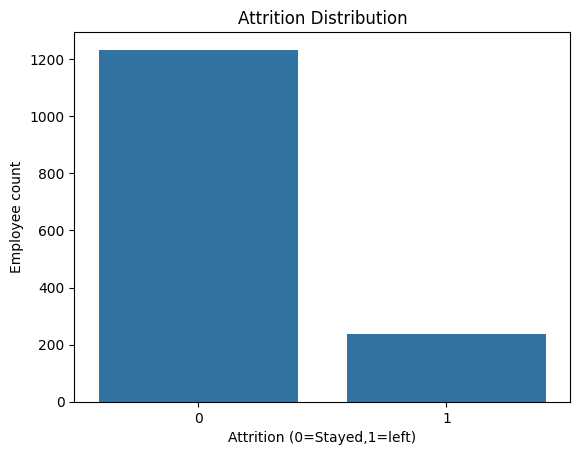

In [16]:
#1. ATTRITION DISTRIBUTION
sns.countplot(x='Attrition',data=df)
plt.title('Attrition Distribution')
plt.xlabel('Attrition (0=Stayed,1=left)')
plt.ylabel('Employee count')
plt.show()


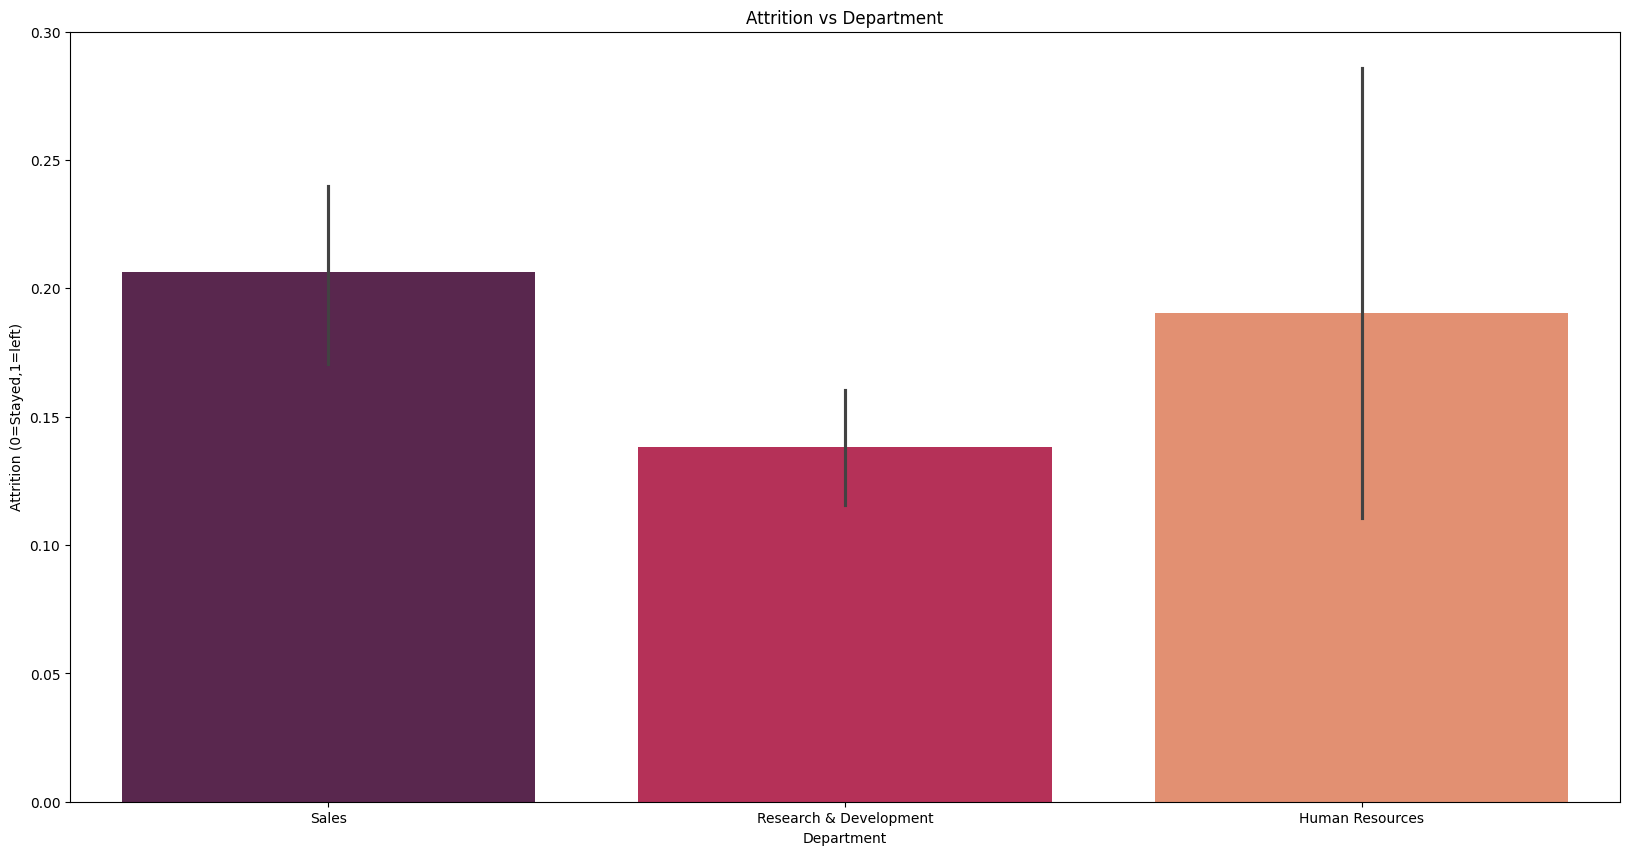

In [17]:
#2.Attrition vs Department
plt.figure(figsize=(20,10))
sns.barplot(x='Department', y='Attrition', data=df,hue='Department',palette="rocket")
plt.title('Attrition vs Department')
plt.xlabel('Department')
plt.ylabel('Attrition (0=Stayed,1=left)')
plt.show()

#This analysis shows the average attrition rate across different departments. 
#Since attrition is a binary variable, the mean value represents the proportion 
# of employees who left the organization in each department.This helps identify departments 
# with higher employee turnover.

In [18]:
#3.Attrition vs Overtime

#Filter employees who left
attrition_yes=df[df['Attrition']==1]

# Count Overtime values
overtime_counts=attrition_yes['OverTime'].value_counts()
overtime_counts


OverTime
Yes    127
No     110
Name: count, dtype: int64

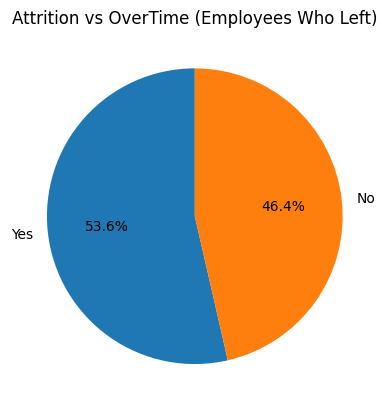

In [19]:

plt.pie(overtime_counts,labels=overtime_counts.index, autopct='%1.1f%%',startangle=90)
plt.title('Attrition vs OverTime (Employees Who Left)')
plt.show()

#A pie chart was used to analyze the proportion of employees who left the organization based on overtime status.
# The visualization shows the percentage distribution of attrition among employees who worked overtime versus those who did not,
# highlighting the potential impact of overtime on employee turnover.

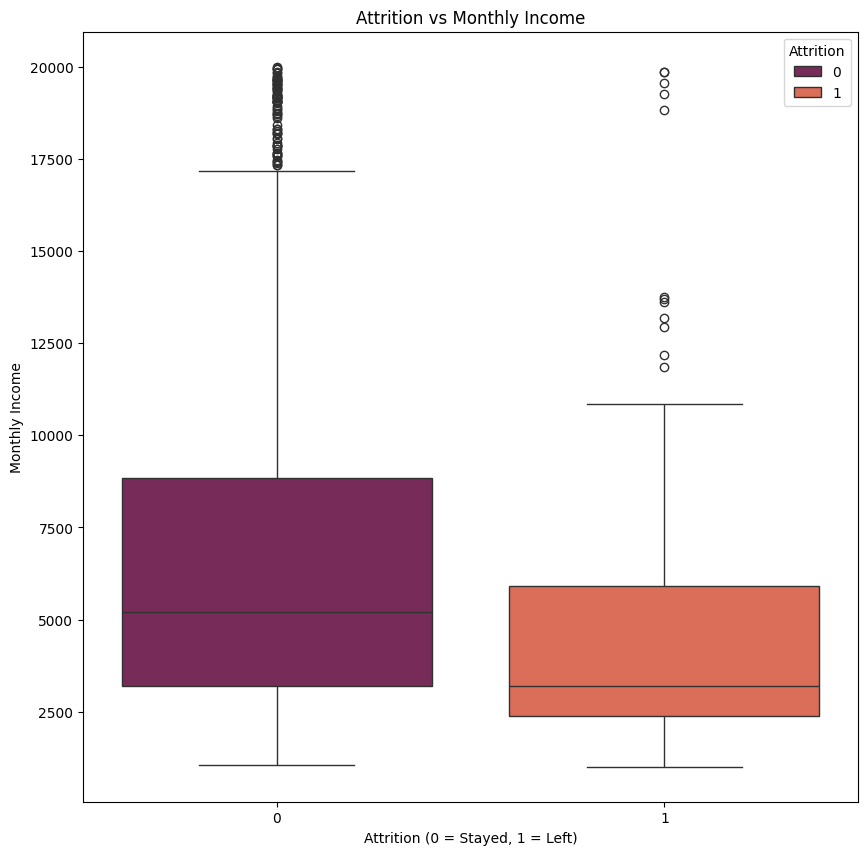

In [20]:
#4.Attrition vs MonthlyIncome

plt.figure(figsize=(10,10))
sns.boxplot(x='Attrition',y='MonthlyIncome',data=df,hue='Attrition',palette="rocket")
plt.title('Attrition vs Monthly Income')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Monthly Income')
plt.show()

#A boxplot was used to analyze the relationship between employee attrition and monthly income. 
# The visualization compares the income distribution of employees who stayed with those who left, 
# helping to understand whether lower income levels are associated with higher attrition.

In [21]:
categorical_col,numerical_col

(Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
        'JobRole', 'MaritalStatus', 'OverTime'],
       dtype='object'),
 Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
        'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
        'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
        'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
        'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
        'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
        'YearsSinceLastPromotion', 'YearsWithCurrManager'],
       dtype='object'))

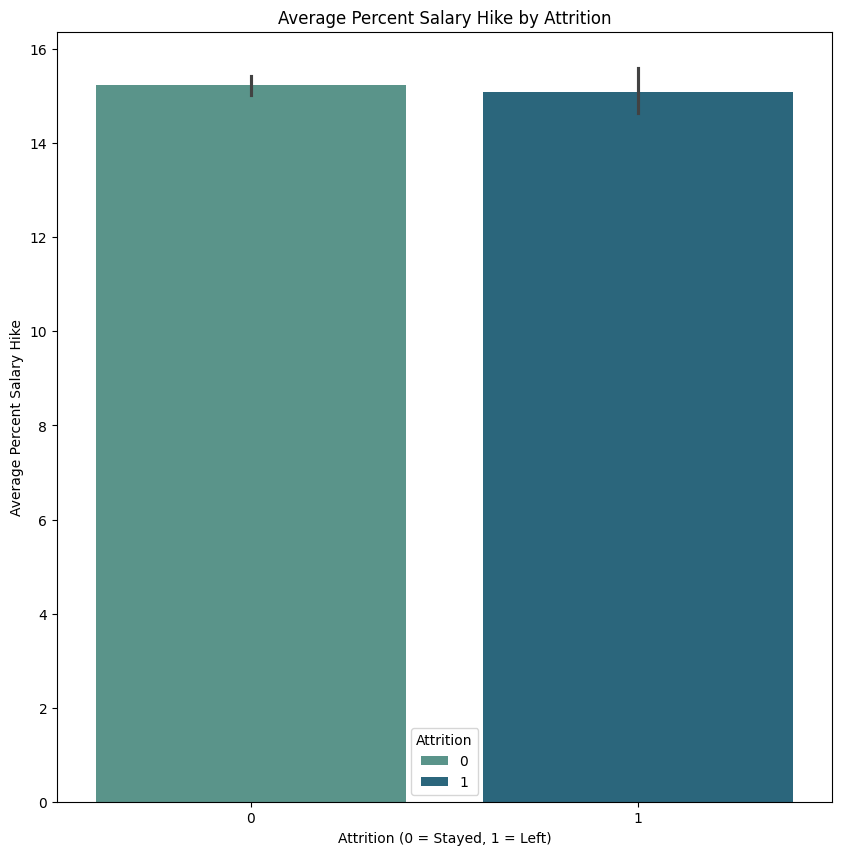

In [22]:
#5.Attrition vs PercentSalaryHike

plt.figure(figsize=(10,10))
sns.barplot(x='Attrition',y='PercentSalaryHike',data=df,hue='Attrition',palette='crest')
plt.title('Average Percent Salary Hike by Attrition')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Average Percent Salary Hike')
plt.show()



In [23]:
df['WorkLifeBalance'].value_counts()

WorkLifeBalance
3    893
2    344
4    153
1     80
Name: count, dtype: int64

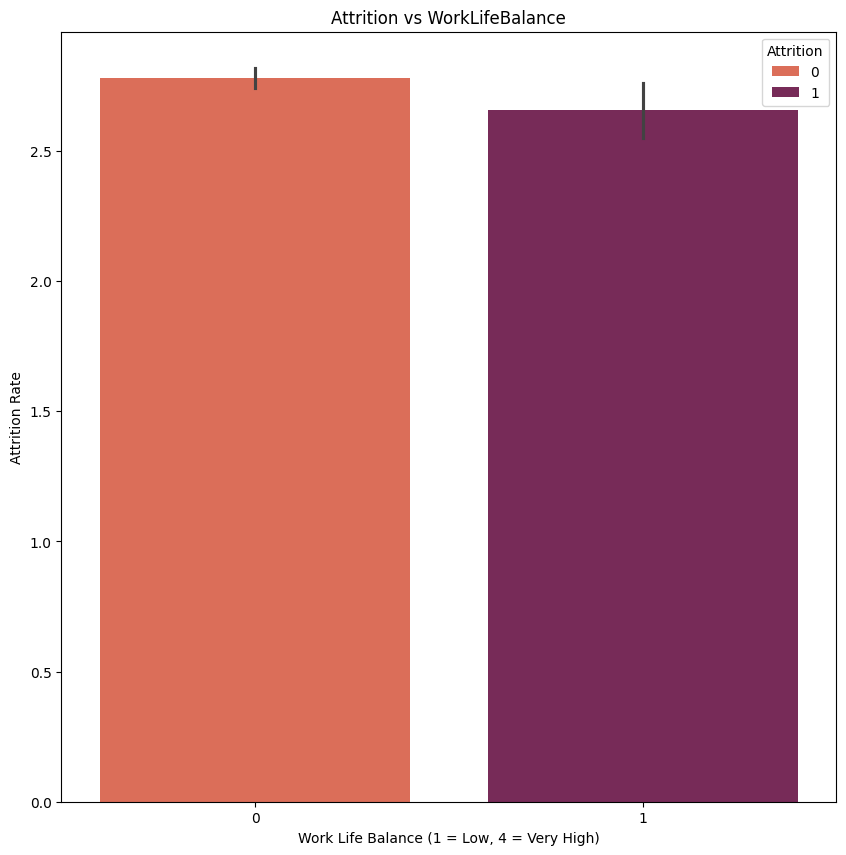

In [24]:
#Attrition vs WorkLifeBalance

plt.figure(figsize=(10,10))
sns.barplot(x='Attrition', y='WorkLifeBalance', data=df,hue='Attrition',palette='rocket_r')
plt.title('Attrition vs WorkLifeBalance')
plt.xlabel('Work Life Balance (1 = Low, 4 = Very High)')
plt.ylabel('Attrition Rate')
plt.show()

#A bar plot was used to analyze the relationship between work-life balance and employee attrition.
# The visualization shows the average attrition rate across different work-life balance levels,
#  helping to understand how work-life balance influences employee turnover.

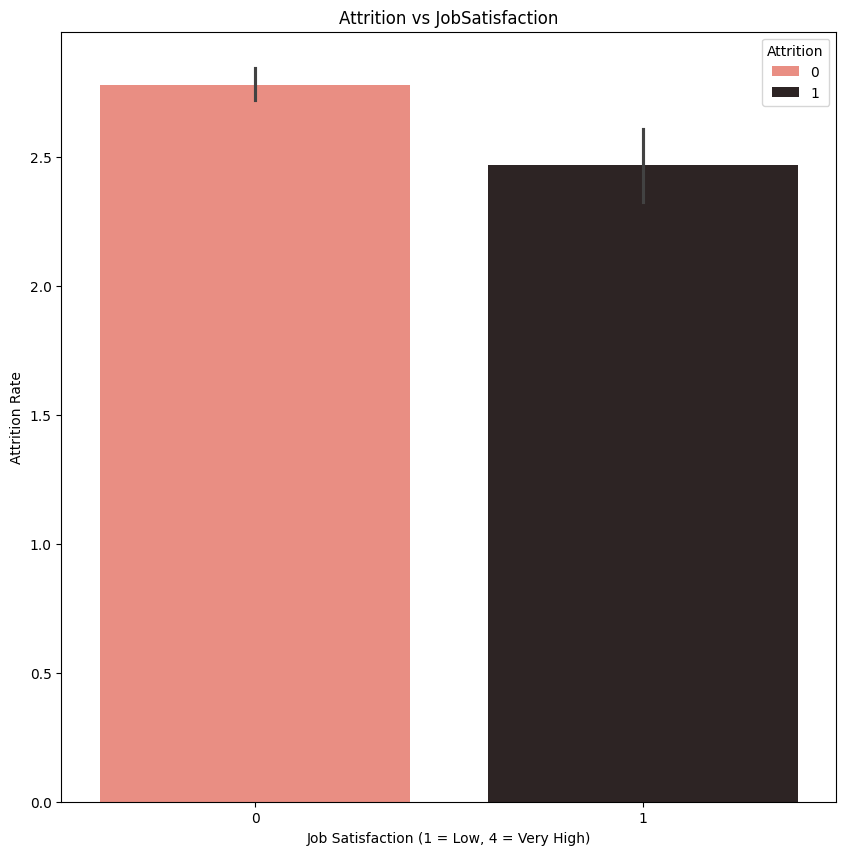

In [25]:
#Attrition vs JobSatisfaction

plt.figure(figsize=(10,10))
sns.barplot(x='Attrition', y='JobSatisfaction', data=df,hue='Attrition',palette='dark:salmon_r')
plt.title('Attrition vs JobSatisfaction')
plt.xlabel('Job Satisfaction (1 = Low, 4 = Very High)')
plt.ylabel('Attrition Rate')
plt.show()

#A bar plot was used to analyze the relationship between job satisfaction and employee attrition. 
# The visualization shows the average attrition rate across different job satisfaction levels, 
# helping identify whether lower satisfaction is associated with higher employee turnover.

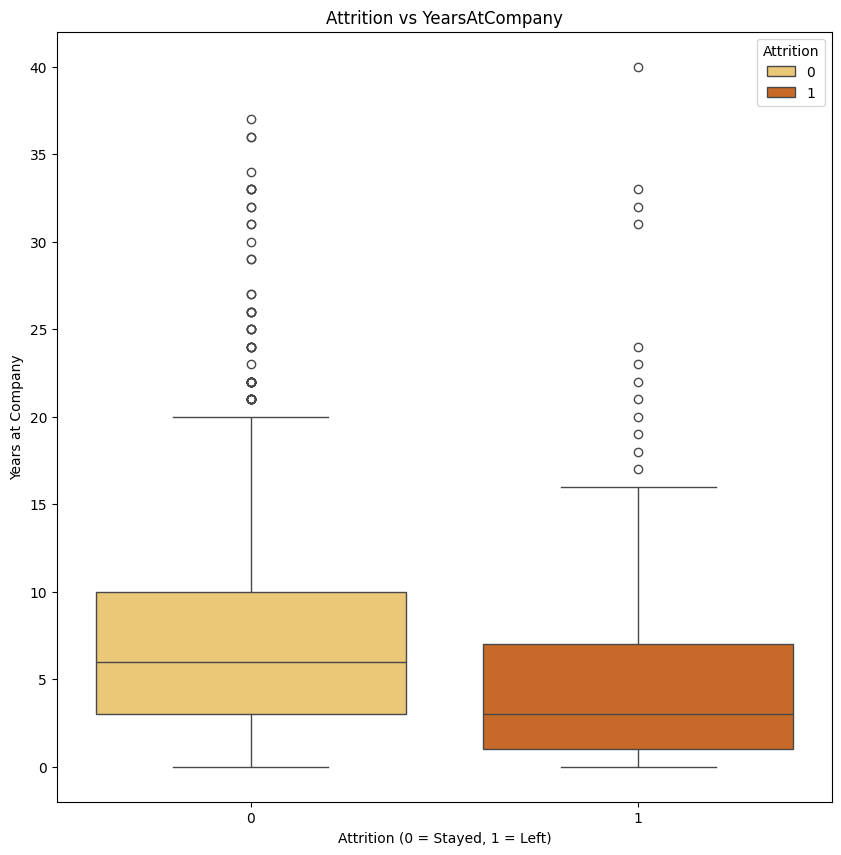

In [26]:
#Attrition vs YearsAtCompany

plt.figure(figsize=(10,10))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df,hue='Attrition',palette="YlOrBr")
plt.title('Attrition vs YearsAtCompany')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Years at Company')
plt.show()

#A boxplot was used to compare the distribution of years at company between employees who stayed and those who left the organization.
# This analysis helps understand whether employee tenure is associated with higher attrition.

##### Exploratory Data Analysis revealed that employees with low job satisfaction,frequent overtime,and shorter tenure are more likely to leave the organization. These factors indicate potential dissatisfaction and work-related stress, which contribute significantly to attrition risk.

In [27]:
#Feature engineering

def tenure_groups(years):
    if years<=2:
        return 'New'
    elif years<=5:
        return 'Mid'
    else:
        return 'Senior'
    
df['Tenure_group']=df['YearsAtCompany'].apply(tenure_groups)

In [28]:
df[['Tenure_group','YearsAtCompany']].head()

#I engineered a tenure-based feature by grouping employees into experience categories,
# as tenure showed a strong relationship with attrition during EDA. 
# This helped improve interpretability and align features with business understanding.

,Tenure_group,YearsAtCompany
0,Senior,6
1,Senior,10
2,New,0
3,Senior,8
4,New,2


In [29]:
categorical_col

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')

In [30]:
X=df.drop('Attrition',axis=1)
Y=df['Attrition']

In [31]:
X_encoded=pd.get_dummies(X,drop_first=True)

#One-hot encoding was applied to categorical input features using get_dummies,
# converting them into numerical format suitable for machine learning models. 
# The drop_first parameter was used to avoid multicollinearity.

In [32]:
numerical_col

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [33]:
X_encoded.shape
X_encoded.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,Tenure_group_New,Tenure_group_Senior
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,True,False,False,True,True,False,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,True,False,False,True,False,False,False,True
2,37,1373,2,2,4,92,2,1,3,2090,...,False,False,False,False,False,False,True,True,True,False
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,True,False,False,True,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,False,False,False,False,False,True,False,False,True,False


In [34]:
X_encoded = X_encoded.astype(int)
X_encoded


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,Tenure_group_New,Tenure_group_Senior
0,41,1102,1,2,2,94,3,2,4,5993,...,0,0,0,1,0,0,1,1,0,1
1,49,279,8,1,3,61,2,2,2,5130,...,0,0,1,0,0,1,0,0,0,1
2,37,1373,2,2,4,92,2,1,3,2090,...,0,0,0,0,0,0,1,1,1,0
3,33,1392,3,4,4,56,3,1,3,2909,...,0,0,1,0,0,1,0,1,0,1
4,27,591,2,1,1,40,3,1,2,3468,...,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,2,4,2571,...,0,0,0,0,0,1,0,0,0,0
1466,39,613,6,1,4,42,2,3,1,9991,...,0,0,0,0,0,1,0,0,0,1
1467,27,155,4,3,2,87,4,2,2,6142,...,1,0,0,0,0,1,0,1,0,1
1468,49,1023,2,3,4,63,2,2,2,5390,...,0,0,0,1,0,1,0,0,0,1


In [35]:
X_encoded.select_dtypes(include='object')

""
0
1
2
3
4
...
1465
1466
1467
1468


In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train,X_test,Y_train,Y_test=train_test_split(X_encoded,Y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

#The dataset was split into training and testing sets to evaluate the model’s performance on unseen data.
# An 80–20 split was used, and stratified sampling ensured that the class distribution of the target variable was preserved in both sets.

((1176, 46), (294, 46), (1176,), (294,))

In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
#create the model
Lg=LogisticRegression(max_iter=1200)

#Train the model
Lg.fit(X_train,Y_train)

e:\DS\PROJECTS\EMPLOYEE ATTRITION ANALYSIS & PREDICTION\EMPLOYEE_ATTRITION_PROJECT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [40]:
Y_train_pred=Lg.predict(X_train)
Y_test_pred=Lg.predict(X_test)

Y_train_pred,Y_test_pred

(array([0, 0, 0, ..., 0, 0, 0], shape=(1176,)),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

In [41]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [42]:
#Accuracy

accuracy_train=accuracy_score(Y_train,Y_train_pred)
accuracy_test=accuracy_score(Y_test,Y_test_pred)

accuracy_train,accuracy_test

#The training and testing accuracies are nearly identical,
#indicating that the model generalizes well and does not suffer from overfitting or underfitting.

(0.8622448979591837, 0.8639455782312925)

In [43]:
#Confusion Matrix

cm=confusion_matrix(Y_test,Y_test_pred)
cm

#The confusion matrix shows that the model performs strongly in identifying employees who stayed but has limited 
#ability to detect employees who left.The high number of false negatives indicates that many attrition cases are missed.

array([[250,   5],
       [ 35,   4]])

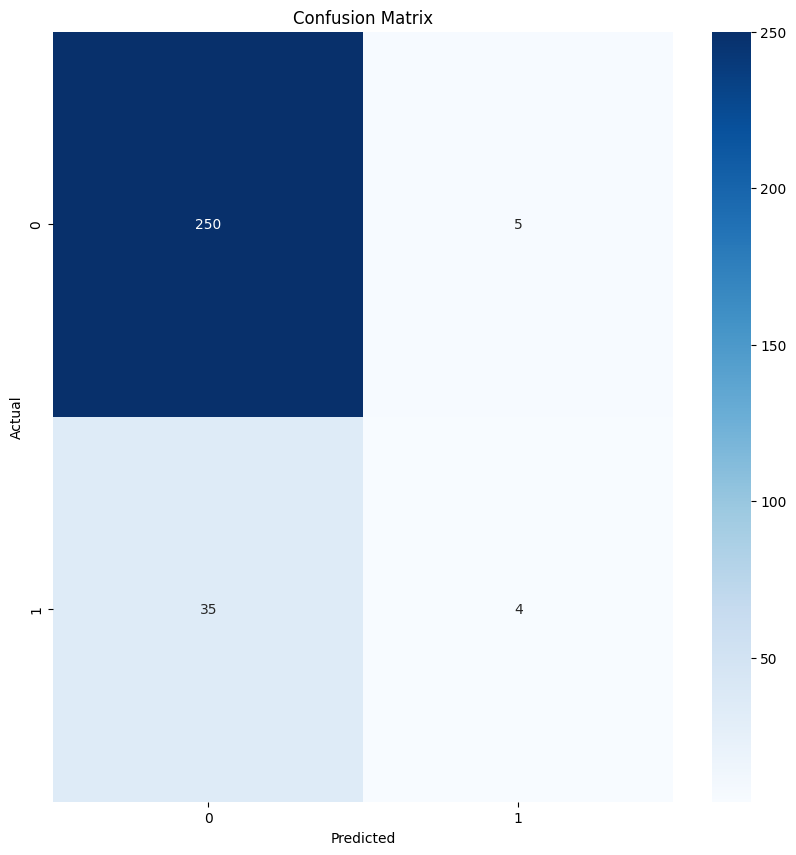

In [71]:
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [74]:
#Classification Report

Y_classi_report=classification_report(Y_test,Y_test_pred)
Y_classi_report

#The trained Logistic Regression model was evaluated using accuracy, confusion matrix, 
# and classification report. These metrics helped assess the model’s ability to correctly 
# classify employees who stayed and those who left the organization.

'              precision    recall  f1-score   support\n\n           0       0.88      0.98      0.93       255\n           1       0.44      0.10      0.17        39\n\n    accuracy                           0.86       294\n   macro avg       0.66      0.54      0.55       294\nweighted avg       0.82      0.86      0.83       294\n'

###### The Logistic Regression model achieved a test accuracy of approximately 86%, indicating strong overall predictive performance.The training and testing accuracies are nearly identical, suggesting that the model generalizes well without significant overfitting. However, due to class imbalance, accuracy alone does not fully capture the model’s ability to detect employees who leave.

In [46]:
# Probability Ranking for High Risk Employees

probabilities=Lg.predict_proba(X_test)[:,1]

risk_df=X_test.copy()

risk_df['Attrition_probability']=probabilities

top_risk_employees=risk_df.sort_values(by='Attrition_probability',ascending=False)

top_risk_employees



,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,Tenure_group_New,Tenure_group_Senior,Attrition_probability
864,41,906,5,2,1,95,2,1,1,2107,...,0,1,0,0,0,0,0,1,0,0.695751
1319,32,1318,10,4,4,79,3,2,4,4648,...,0,0,1,0,0,1,0,1,0,0.637551
591,33,118,16,3,1,69,3,2,1,5324,...,0,0,1,0,0,1,0,0,0,0.637381
1057,29,115,13,3,1,51,3,2,2,5765,...,0,0,1,0,0,1,0,0,0,0.620163
892,19,504,10,3,1,96,2,1,2,1859,...,0,1,0,0,0,1,1,1,0,0.590731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1054,49,1490,7,4,3,35,3,3,2,10466,...,0,0,0,0,0,0,0,0,1,0.004200
809,28,950,3,3,4,93,3,3,2,7655,...,0,0,0,0,0,0,0,0,1,0.004106
1181,49,465,6,1,3,41,2,4,3,13966,...,0,0,0,0,1,0,1,0,1,0.001880
858,53,1223,7,2,4,50,3,5,3,18606,...,0,0,0,0,0,0,0,0,1,0.001442


###### The model generated attrition probabilities for employees in the test dataset. Employees with the highest predicted probabilities were identified as at-risk individuals. This ranked list enables HR teams to proactively intervene and implement targeted retention strategies.

In [47]:
#AUC-ROC 

from sklearn.metrics import roc_auc_score

auc_roc_score=roc_auc_score(Y_test,probabilities)
print('AUC:',auc_roc_score)

AUC: 0.7399698340874812


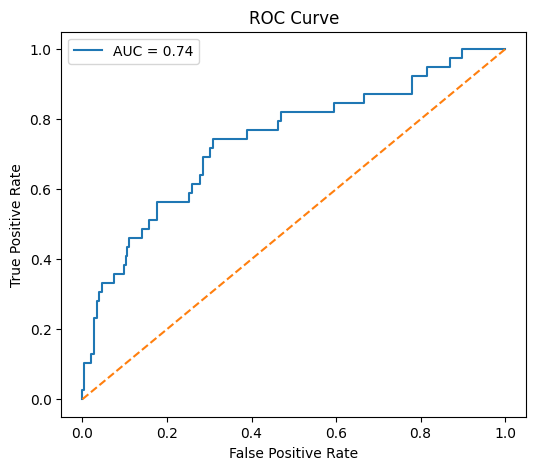

In [48]:
from sklearn.metrics import roc_curve

fpr,tpr,threshold=roc_curve(Y_test,probabilities)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_roc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


###### The AUC–ROC score of approximately 0.74 indicates that the model has a good ability to distinguish between employees who leave and those who stay. This suggests that the model performs better than random guessing and provides meaningful separation between the two classes.

In [76]:
#Model Training Time

import time

start=time.time()
Lg=LogisticRegression(max_iter=1200)
Lg.fit(X_train,Y_train)
end=time.time()

Training_time=end-start
Training_time

#The model training time was minimal (e.g., 1.2 seconds),indicating computational efficiency for this dataset size

e:\DS\PROJECTS\EMPLOYEE ATTRITION ANALYSIS & PREDICTION\EMPLOYEE_ATTRITION_PROJECT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


1.11745285987854

##### Performance Rating Prediction

In [50]:
X_perf = df.drop(['PerformanceRating', 'Attrition'], axis=1)
Y_perf=df['PerformanceRating']

In [51]:
X_perf_encoded=pd.get_dummies(X_perf,drop_first=True)

In [52]:
X_perf_encoded = X_perf_encoded.astype(int)
X_perf_encoded

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,Tenure_group_New,Tenure_group_Senior
0,41,1102,1,2,2,94,3,2,4,5993,...,0,0,0,1,0,0,1,1,0,1
1,49,279,8,1,3,61,2,2,2,5130,...,0,0,1,0,0,1,0,0,0,1
2,37,1373,2,2,4,92,2,1,3,2090,...,0,0,0,0,0,0,1,1,1,0
3,33,1392,3,4,4,56,3,1,3,2909,...,0,0,1,0,0,1,0,1,0,1
4,27,591,2,1,1,40,3,1,2,3468,...,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,2,4,2571,...,0,0,0,0,0,1,0,0,0,0
1466,39,613,6,1,4,42,2,3,1,9991,...,0,0,0,0,0,1,0,0,0,1
1467,27,155,4,3,2,87,4,2,2,6142,...,1,0,0,0,0,1,0,1,0,1
1468,49,1023,2,3,4,63,2,2,2,5390,...,0,0,0,1,0,1,0,0,0,1


In [53]:
X_train_p,X_test_p,Y_train_p,Y_test_p=train_test_split(X_perf_encoded,Y_perf,test_size=0.2,random_state=42)
X_train_p.shape,Y_train_p.shape,X_test_p.shape,Y_test_p.shape

((1176, 45), (1176,), (294, 45), (294,))

In [54]:
#create the model
Lg_p=LogisticRegression(max_iter=1000,class_weight='balanced')

#Train the model
Lg_p.fit(X_train_p,Y_train_p)

e:\DS\PROJECTS\EMPLOYEE ATTRITION ANALYSIS & PREDICTION\EMPLOYEE_ATTRITION_PROJECT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [55]:
Y_train_p_pred=Lg_p.predict(X_train_p)
Y_test_p_pred=Lg_p.predict(X_test_p)

Y_train_p_pred,Y_test_p_pred

(array([3, 3, 3, ..., 3, 3, 3], shape=(1176,)),
 array([3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3,
        3, 4, 3, 3, 4, 4, 3, 3, 3, 3, 4, 3, 3, 3, 3, 4, 3, 4, 4, 3, 3, 3,
        3, 4, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 4, 3, 3, 3, 4, 3,
        4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 4, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 4, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 4, 4, 3, 3, 3, 3, 3, 3, 4, 3, 3, 4, 3, 3, 4, 3, 3, 3, 3, 4, 3,
        3, 3, 4, 3, 3, 3, 3, 3, 4, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 4, 3, 4,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 4, 3, 3,
        3, 3, 4, 3, 3, 3, 3, 3, 3, 4, 3, 4, 4, 4, 4, 3, 4, 3, 3, 3, 4, 3,
        4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 3, 3, 4, 3, 4, 3, 4, 3, 3,
        3, 3, 3, 3, 3, 3, 4, 3, 3, 4, 3, 3, 3, 4, 3, 3, 3, 3, 3,

In [56]:
#Accuracy score

accuracy_train_p=accuracy_score(Y_train_p,Y_train_p_pred)
accuracy_test_p=accuracy_score(Y_test_p,Y_test_p_pred)

accuracy_train_p,accuracy_test_p

(0.907312925170068, 0.9251700680272109)

In [57]:
#Confusion Matrix

cm_p=confusion_matrix(Y_test_p,Y_test_p_pred)
cm_p

array([[231,  20],
       [  2,  41]])

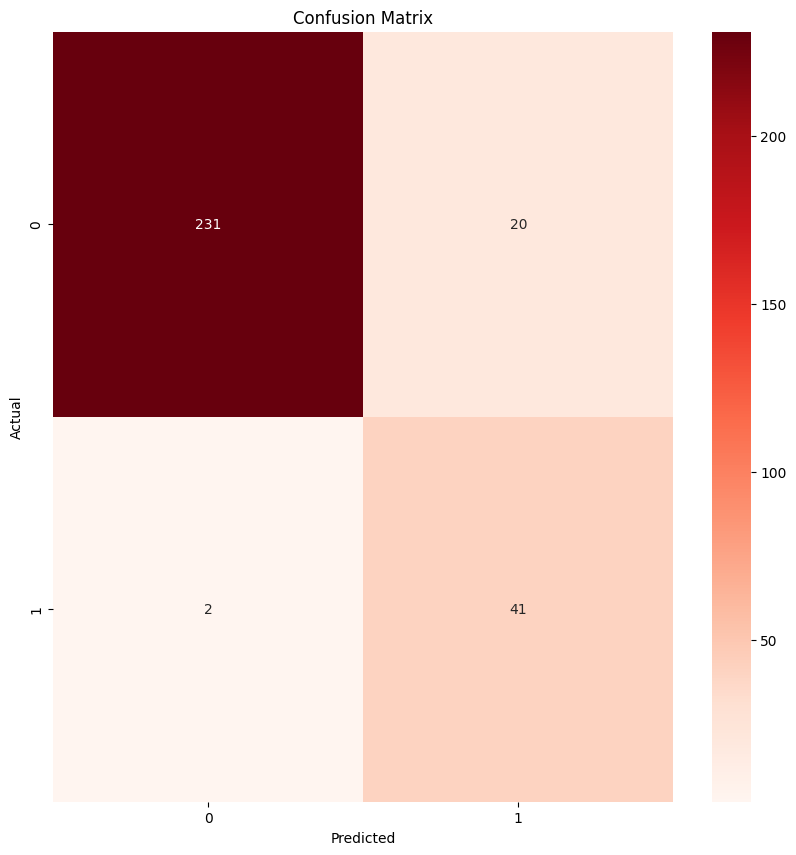

In [58]:
plt.figure(figsize=(10,10))
sns.heatmap(cm_p,annot=True,fmt='d',cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [59]:
#Classification Report

Y_p_classi_report=classification_report(Y_test_p,Y_test_p_pred)
Y_p_classi_report

'              precision    recall  f1-score   support\n\n           3       0.99      0.92      0.95       251\n           4       0.67      0.95      0.79        43\n\n    accuracy                           0.93       294\n   macro avg       0.83      0.94      0.87       294\nweighted avg       0.94      0.93      0.93       294\n'

In [60]:
# Probability Ranking for Performance Rating 

performance_prob=Lg_p.predict_proba(X_test_p)[:,1]

performance_df=X_test_p.copy()

performance_df['Performance_probability']=performance_prob

top_performance_employees=performance_df.sort_values(by='Performance_probability',ascending=False)

top_performance_employees


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,Tenure_group_New,Tenure_group_Senior,Performance_probability
892,19,504,10,3,1,96,2,1,2,1859,...,0,1,0,0,0,1,1,1,0,0.999930
1087,34,1440,7,2,2,55,3,1,3,2308,...,0,0,0,1,1,0,1,0,1,0.999791
1307,28,1217,1,3,3,67,3,1,1,3591,...,0,1,0,0,1,0,0,0,0,0.998991
882,36,363,1,3,3,77,1,3,1,10252,...,0,0,0,0,0,0,1,0,1,0.998955
277,38,322,7,2,1,44,4,2,1,5605,...,0,0,1,0,0,0,1,0,1,0.998818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,35,1182,11,2,4,54,3,2,4,4968,...,0,0,1,0,0,0,0,0,0,0.000029
462,34,258,21,4,4,74,4,2,4,5337,...,0,0,1,0,0,1,0,0,1,0.000026
1422,35,1490,11,4,4,43,3,1,3,2660,...,0,0,0,0,1,0,1,1,0,0.000021
1250,29,461,1,3,4,70,4,2,3,6294,...,0,0,0,0,0,1,1,0,0,0.000014


##### Impact of Retention Strategies

###### By identifying high-risk employees early, HR departments can implement targeted retention strategies such as improving job satisfaction, reducing overtime burden, and offering career development opportunities.These proactive measures can help reduce overall attrition rates, lower recruitment costs, and enhance employee engagement.

In [62]:
import pickle

# Save attrition model
pickle.dump(Lg, open("attrition_model.pkl", "wb"))

# Save performance model
pickle.dump(Lg_p, open("performance_model.pkl", "wb"))

In [64]:
# Attrition feature columns
feature_columns_attrition = X_train.columns
pickle.dump(feature_columns_attrition, open("feature_columns_attrition.pkl", "wb"))


In [65]:
# Performance feature columns
feature_columns_perf = X_train_p.columns
pickle.dump(feature_columns_perf, open("feature_columns_perf.pkl", "wb"))


In [66]:
feature_columns_attrition = pickle.load(open("feature_columns_attrition.pkl", "rb"))
feature_columns_perf = pickle.load(open("feature_columns_perf.pkl", "rb"))



In [67]:
input_df_attrition = pd.DataFrame(columns=feature_columns_attrition)
input_df_attrition.loc[0] = 0

In [68]:
input_df_perf = pd.DataFrame(columns=feature_columns_perf)
input_df_perf.loc[0] = 0

In [69]:
df.to_csv("employee_data.csv", index=False)
